# EDA Assignment

---

**EDA Project Instructions**

1. **Read Each Task Carefully**: Understand each task’s requirements before starting your analysis.

2. **Perform the Analysis**: For each task, you’ll find a description in the code cell. Write your code directly in the provided cells to perform the necessary analysis using the Heart Attack dataset.

3. **Visualize and Interpret**: Create visualizations and interpret the results as needed. Ensure your analysis addresses the specific questions and insights required.

4. **Complete All Tasks**: Make sure you address each task. Each task is designed to test different aspects of data analysis and visualization.

5. **Download Your Notebook**: After completing and reviewing your analysis, download your notebook file (.ipynb) by selecting `File > Download > Download .ipynb`.

6. **Submit Your Work**: Upload the downloaded `.ipynb` file to the designated platform for submission.

7. **Verify Your Submission**: Ensure that you have submitted the correct file and that it is not corrupted. If needed, resubmit the file.

Good luck, and happy analyzing!

---

## Dataset Information :
<ul style= "color:#137667;
            font-size:12px;">
    <li> age : age of the patient</li>
    <li> sex : sex of the patient (0 - Male, 1 - Female)</li>
    <li> cp : Chest Pain type</li>
    0: typical angina <br>
    1: atypical angina <br>
    2: non-anginal pain <br>
    3: asymptomatic <br>
    <li> trtbps : resting blood pressure (in mm Hg)</li>
    <li> fbs : (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)</li>
    <li> chol : cholestoral in mg/dl fetched via BMI sensor</li>
    <li> rest_ecg : resting electrocardiographic results</li>
  0:normal <br>
  1:having ST-T wave abnormality(T wave inversions and/or ST elevation or depression of>0.05 mV) <br>
  2:showing probable or definite left ventricular hypertrophy by Estes' criteria
    <li> thalachh : maximum heart rate achieved</li>
    <li> exng : exercise induced angina (1 = yes; 0 = no)</li>
    <li> oldpeak : Previous peak</li>
    <li> slp : ST/HR Slope </li>
    <li> caa : number of major vessels (0-4)</li>
    <li> thall : Thal rate</li>
    <li> output : 0= less chance of heart attack 1= more chance of heart attack</li>
</ul>

In [1]:
# Run this code cell for initial setup
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

# load the data to colab
data = pd.read_csv('https://new-assets.ccbp.in/frontend/content/aiml/math-for-ml/heart_cleaned_data.csv')
data.head(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233.0,1,0,150.0,0.0,2.3,0,0,1,1
1,37,1,2,130,250.0,0,1,187.0,0.0,3.5,0,0,2,1
2,41,0,1,130,204.0,0,0,172.0,0.0,1.4,2,0,2,1
3,56,1,1,120,236.0,0,1,178.0,0.0,0.8,2,0,2,1
4,57,0,0,120,354.0,0,1,163.0,1.0,0.6,2,0,2,1
5,57,1,0,140,192.0,0,1,148.0,0.0,0.4,1,0,1,1
6,56,0,1,140,294.0,0,0,153.0,0.0,1.3,1,0,2,1
7,44,1,1,120,263.0,0,1,173.0,0.0,0.0,2,0,3,1
8,52,1,2,172,199.0,1,1,162.0,0.0,0.5,2,0,3,1
9,57,1,2,150,168.0,0,1,174.0,0.0,1.6,2,0,2,1


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trtbps    302 non-null    int64  
 4   chol      302 non-null    float64
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalachh  302 non-null    float64
 8   exng      302 non-null    float64
 9   oldpeak   302 non-null    float64
 10  slp       302 non-null    int64  
 11  caa       302 non-null    int64  
 12  thall     302 non-null    int64  
 13  output    302 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 33.2 KB


---
---
**1. Check does patients with exercise-induced angina (exng) at higher risk of heart attack, sort by exng ascending and round to 2 decimals.**

Print with `Heart attack risk by exercise-induced angina (exng):`

In [22]:
exng_risk = data.groupby('exng')['output'].mean().round(2).sort_values(ascending=True)
print("Heart attack risk by exercise-induced angina (exng):")
print(exng_risk)

Heart attack risk by exercise-induced angina (exng):
exng
1.0    0.22
0.0    0.70
Name: output, dtype: float64


---
---
**2. Which thalassemia (thall) category is associated with the highest risk of heart attack, sort in descending order, and round the results to 2 decimals.**

Print with `Heart attack risk by thalassemia (thall):`

In [23]:
thall_risk = data.groupby('thall')['output'].mean().round(2).sort_values(ascending=False)
print("Heart attack risk by thalassemia (thall):")
print(thall_risk)

Heart attack risk by thalassemia (thall):
thall
2    0.78
0    0.50
1    0.33
3    0.24
Name: output, dtype: float64


---
---
**3.Determine mean, standard deviation and quartiles(Q1,median,Q3) for following columns: age, trtbps, chol, thalachh, round the results to 0 decimals.**

In [24]:
selected_columns = ['age', 'trtbps', 'chol', 'thalachh']
descriptive_stats = data[selected_columns].describe().loc[['mean', 'std', '25%', '50%', '75%']].round(0)
print(descriptive_stats)

       age  trtbps   chol  thalachh
mean  54.0   132.0  246.0     150.0
std    9.0    18.0   51.0      23.0
25%   48.0   120.0  212.0     134.0
50%   56.0   130.0  242.0     152.0
75%   61.0   140.0  274.0     166.0


---
---
**4.Analyse whether males or females are at a higher risk of heart attack?**

Print with `Heart attack risk by sex (0=Male, 1=Female):`

In [25]:
sex_risk = data.groupby('sex')['output'].mean().round(2)
print("Heart attack risk by sex (0=Male, 1=Female):")
print(sex_risk)

Heart attack risk by sex (0=Male, 1=Female):
sex
0    0.75
1    0.45
Name: output, dtype: float64


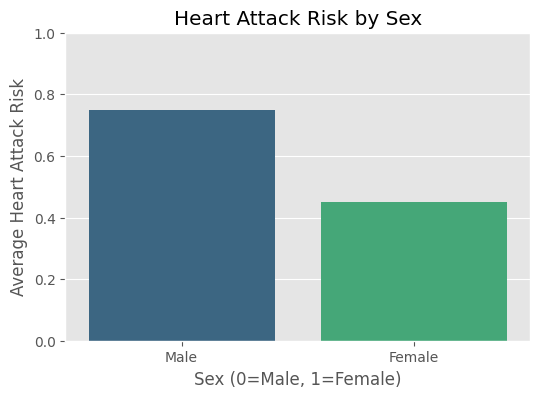

In [26]:
plt.figure(figsize=(6, 4))
sns.barplot(x=sex_risk.index, y=sex_risk.values, palette='viridis')
plt.title('Heart Attack Risk by Sex')
plt.xlabel('Sex (0=Male, 1=Female)')
plt.ylabel('Average Heart Attack Risk')
plt.xticks([0, 1], ['Male', 'Female'])
plt.ylim(0, 1)
plt.show()

**5.Patients with which type of chest pain are at highest risk of heart attack?**

Print with `Heart attack risk by chest pain type:`

In [27]:
cp_risk = data.groupby('cp')['output'].mean().round(2).sort_values(ascending=False)
print("Heart attack risk by chest pain type:")
print(cp_risk)

Heart attack risk by chest pain type:
cp
1    0.82
2    0.79
3    0.70
0    0.27
Name: output, dtype: float64


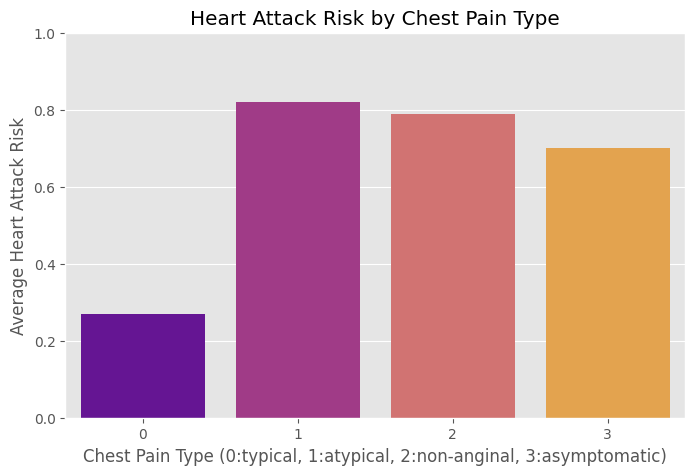

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(x=cp_risk.index, y=cp_risk.values, palette='plasma')
plt.title('Heart Attack Risk by Chest Pain Type')
plt.xlabel('Chest Pain Type (0:typical, 1:atypical, 2:non-anginal, 3:asymptomatic)')
plt.ylabel('Average Heart Attack Risk')
plt.ylim(0, 1)
plt.show()

---
---
**6.Analyse the effect of age on heart attack risk.**

In [29]:
age_risk = data.groupby('age')['output'].mean().round(2)
print("Heart attack risk by age (mean output):")
print(age_risk.head())

young_mean_age = data[data['output'] == 1]['age'].mean().round(0)
old_mean_age = data[data['output'] == 0]['age'].mean().round(0)
print(f"\nMean age for higher risk: {young_mean_age}")
print(f"Mean age for lower risk: {old_mean_age}")

Heart attack risk by age (mean output):
age
29    1.0
34    1.0
35    0.5
37    1.0
38    0.5
Name: output, dtype: float64

Mean age for higher risk: 53.0
Mean age for lower risk: 57.0


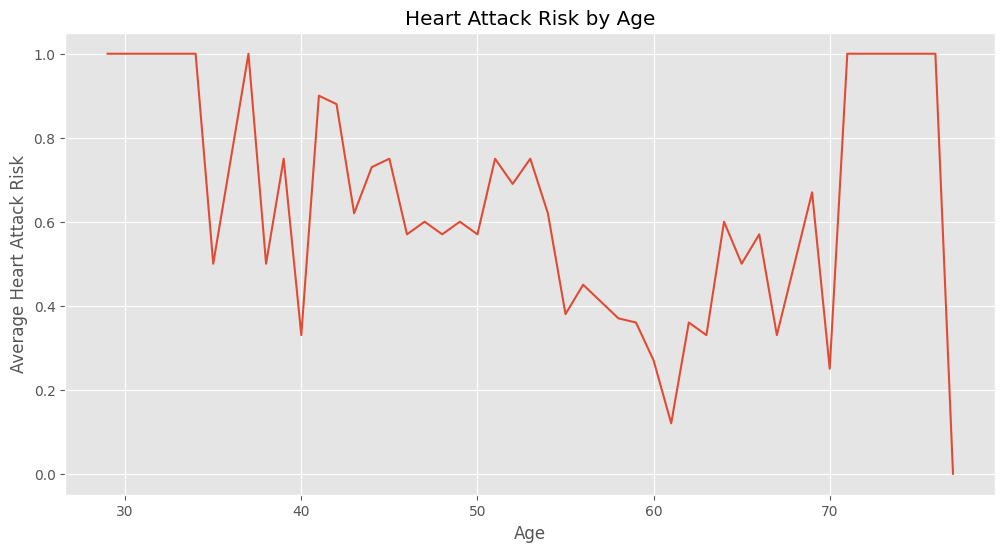

In [30]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=age_risk.index, y=age_risk.values)
plt.title('Heart Attack Risk by Age')
plt.xlabel('Age')
plt.ylabel('Average Heart Attack Risk')
plt.show()

---
---
**7. Does higher risk of `Heart attack risk by fasting blood sugar:` is associated more with low fasting blood sugar levels or high fasting blood sugar levels?**

In [31]:
fbs_risk = data.groupby('fbs')['output'].mean().round(2)
print("Heart attack risk by fasting blood sugar (0=False, 1=True (>120 mg/dl)):")
print(fbs_risk)

Heart attack risk by fasting blood sugar (0=False, 1=True (>120 mg/dl)):
fbs
0    0.55
1    0.51
Name: output, dtype: float64


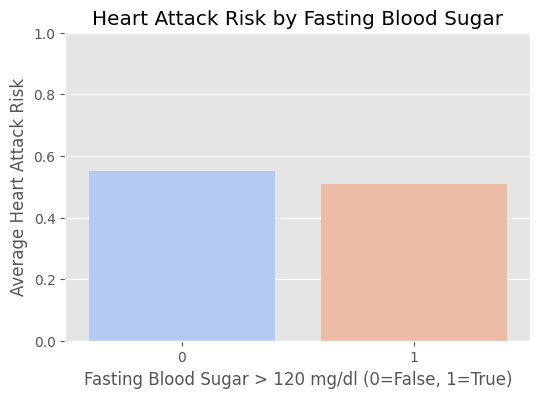

In [32]:
plt.figure(figsize=(6, 4))
sns.barplot(x=fbs_risk.index, y=fbs_risk.values, palette='coolwarm')
plt.title('Heart Attack Risk by Fasting Blood Sugar')
plt.xlabel('Fasting Blood Sugar > 120 mg/dl (0=False, 1=True)')
plt.ylabel('Average Heart Attack Risk')
plt.ylim(0, 1)
plt.show()

---
---
**8. How the risk of `Heart attack risk by resting ECG results:`determined from resting electrocardiographic results?**

In [33]:
restecg_risk = data.groupby('restecg')['output'].mean().round(2).sort_values(ascending=False)
print("Heart attack risk by resting ECG results:")
print(restecg_risk)

Heart attack risk by resting ECG results:
restecg
1    0.63
0    0.46
2    0.25
Name: output, dtype: float64


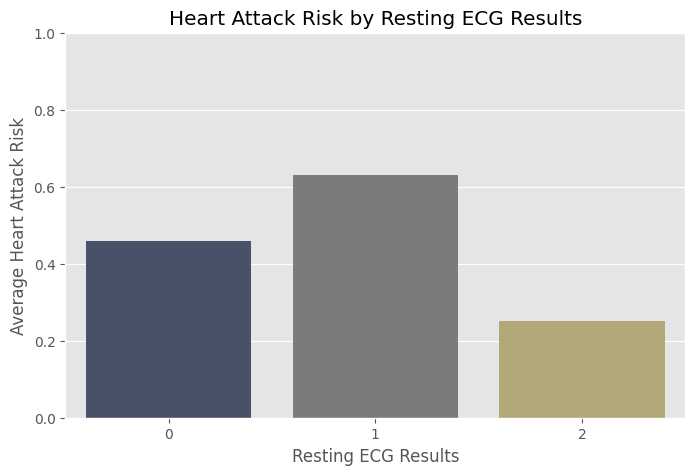

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(x=restecg_risk.index, y=restecg_risk.values, palette='cividis')
plt.title('Heart Attack Risk by Resting ECG Results')
plt.xlabel('Resting ECG Results')
plt.ylabel('Average Heart Attack Risk')
plt.ylim(0, 1)
plt.show()

---
---
**9. Is resting blood presure a significant factor for determining risk of a heart attack?**


Print with `Mean blood pressure by risk:`

In [35]:
trtbps_risk = data.groupby('output')['trtbps'].mean().round(2)
print("Mean blood pressure by risk:")
print(trtbps_risk)

Mean blood pressure by risk:
output
0    134.40
1    129.25
Name: trtbps, dtype: float64


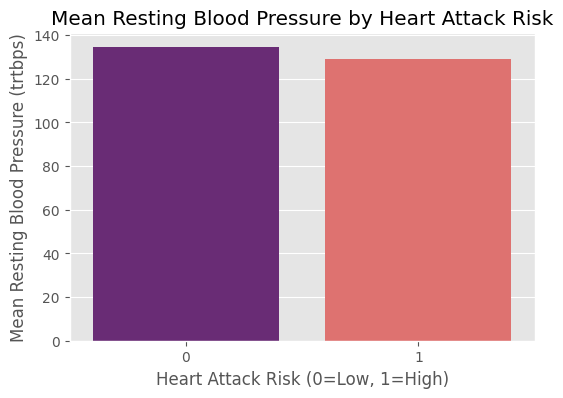

In [36]:
plt.figure(figsize=(6, 4))
sns.barplot(x=trtbps_risk.index, y=trtbps_risk.values, palette='magma')
plt.title('Mean Resting Blood Pressure by Heart Attack Risk')
plt.xlabel('Heart Attack Risk (0=Low, 1=High)')
plt.ylabel('Mean Resting Blood Pressure (trtbps)')
plt.show()

---
---
**10.Is heart attack risk asociated with a higher heart rate?**

In [37]:
thalachh_risk = data.groupby('output')['thalachh'].mean().round(2)
print("Mean maximum heart rate achieved by heart attack risk:")
print(thalachh_risk)

Mean maximum heart rate achieved by heart attack risk:
output
0    139.10
1    158.34
Name: thalachh, dtype: float64


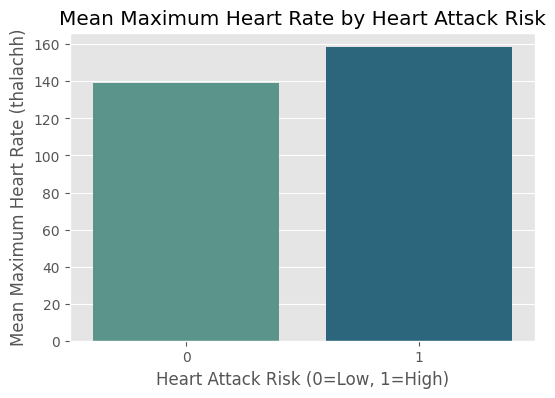

In [38]:
plt.figure(figsize=(6, 4))
sns.barplot(x=thalachh_risk.index, y=thalachh_risk.values, palette='crest')
plt.title('Mean Maximum Heart Rate by Heart Attack Risk')
plt.xlabel('Heart Attack Risk (0=Low, 1=High)')
plt.ylabel('Mean Maximum Heart Rate (thalachh)')
plt.show()

---
---
**11. Determine which ST/HR(ST segment and Heart rate ratio) slope value is associated with the highest risk of heart attack?**

In [39]:
slp_risk = data.groupby('slp')['output'].mean().round(2).sort_values(ascending=False)
print("Heart attack risk by ST/HR slope (slp):")
print(slp_risk)

Heart attack risk by ST/HR slope (slp):
slp
2    0.75
0    0.43
1    0.35
Name: output, dtype: float64


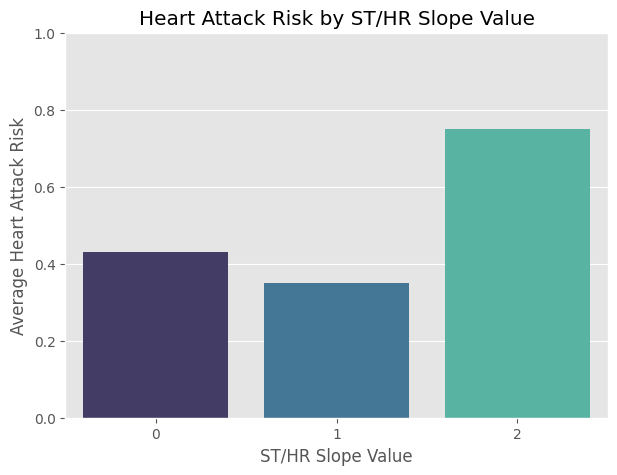

In [40]:
plt.figure(figsize=(7, 5))
sns.barplot(x=slp_risk.index, y=slp_risk.values, palette='mako')
plt.title('Heart Attack Risk by ST/HR Slope Value')
plt.xlabel('ST/HR Slope Value')
plt.ylabel('Average Heart Attack Risk')
plt.ylim(0, 1)
plt.show()

## End!